# Time Series Analysis: Polish National Power Grid (PSE)
## 01. Exploratory Data Analysis, Load Profile, and Stationarity Analysis

**Business Objective:** Identify diurnal and weekly demand cycles, quantify the impact of solar PV and wind generation on net demand (the Duck Curve phenomenon), and verify stationarity properties before predictive modeling.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL

sys.path.append(os.path.abspath('..'))
from src.time_series_utils import check_stationarity
from src.visualization import plot_time_series_overview, plot_decomposition, plot_acf_pacf_custom

%matplotlib inline
plt.rcParams['figure.dpi'] = 100


### 1. Data Ingestion & Preprocessing (1-Hour Aggregation)

In [2]:
raw_data_path = '../data/raw/pse_energy_data.csv'
df_raw = pd.read_csv(raw_data_path)
df_raw['dtime'] = pd.to_datetime(df_raw['dtime'])
df_raw = df_raw.sort_values('dtime').set_index('dtime')

# Resample from 15-min intervals to 1-hour means
df = df_raw.resample('1h').mean().interpolate(method='time')
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/pse_hourly_data.csv')

print(f"Data range: {df.index.min()} to {df.index.max()}")
print(f"Total hourly observations: {len(df)}")
df.head(3)


Data range: 2024-06-14 00:00:00 to 2024-07-15 05:00:00
Total hourly observations: 750


,demand,pv,wi,jg,oze_total,net_demand
dtime,,,,,,
2024-06-14 00:00:00,15882.56525,0.0,314.68250,11845.52125,314.68250,15567.88275
2024-06-14 01:00:00,15508.69350,0.0,375.03500,11280.18325,375.03500,15133.65850
2024-06-14 02:00:00,15107.99550,0.0,465.57575,10061.82725,465.57575,14642.41975


### 2. Time Series Overview: Demand, Renewable Generation (PV/Wind), and Conventional Units

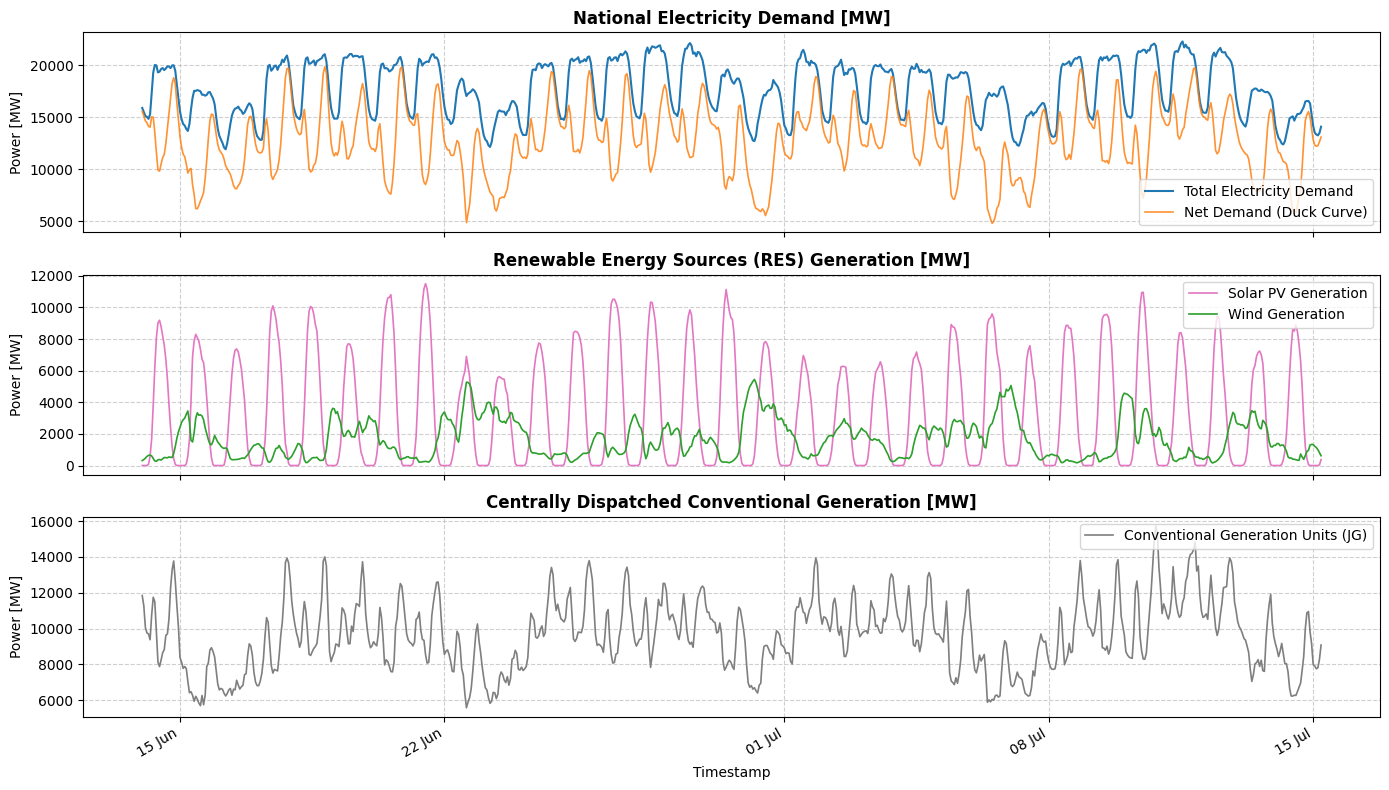

In [3]:
fig = plot_time_series_overview(df)
plt.show()


### 3. Diurnal Load Profile, RES Generation, and the Duck Curve Effect

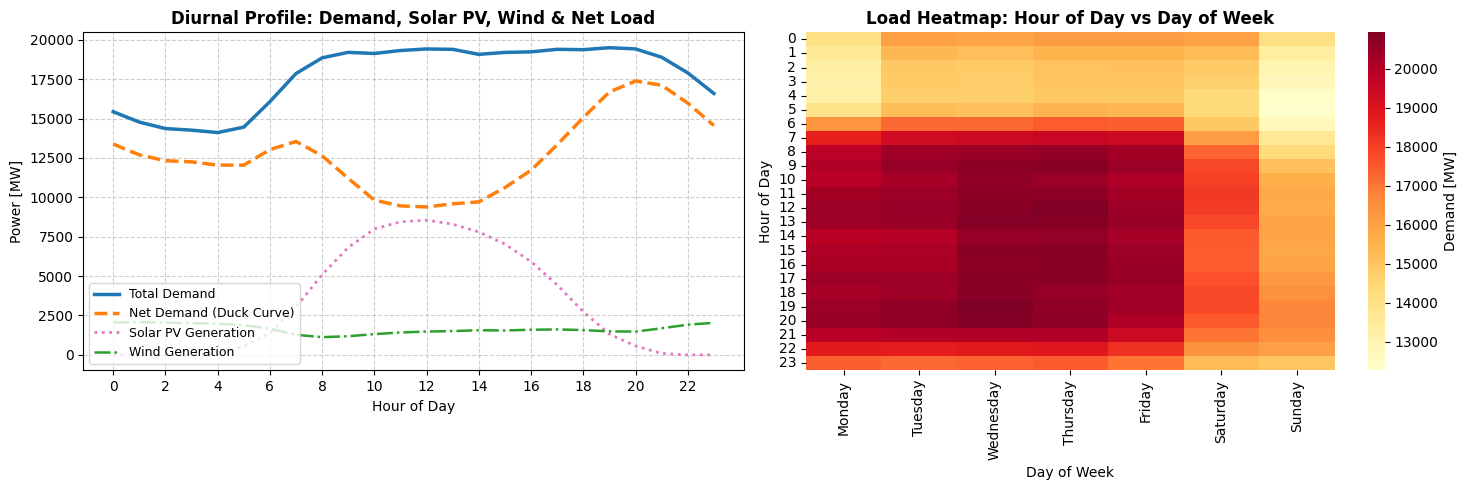

--- LOAD PROFILE & RES STATISTICS ---
Mean night demand (02:00-04:00): 14246.0 MW
Mean day demand (09:00-19:00): 19292.8 MW
Mean demand: Workdays = 18590.3 MW | Weekends = 15781.1 MW (Weekend reduction: 2809.2 MW)
Midday (12:00): Demand = 19416.8 MW | Solar PV = 8549.4 MW | Wind = 1478.8 MW | Net Demand = 9388.6 MW
Evening Peak (20:00): Demand = 19418.9 MW | Net Demand = 17379.3 MW (Net load ramp 12:00 -> 20:00: 7990.7 MW)


In [4]:
df_analysis = df.copy()
df_analysis['hour'] = df_analysis.index.hour
df_analysis['dayofweek'] = df_analysis.index.day_name()
df_analysis['is_weekend'] = df_analysis.index.dayofweek.isin([5, 6])

hourly_demand = df_analysis.groupby('hour')['demand'].mean()
hourly_net = df_analysis.groupby('hour')['net_demand'].mean()
hourly_pv = df_analysis.groupby('hour')['pv'].mean()
hourly_wi = df_analysis.groupby('hour')['wi'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(hourly_demand.index, hourly_demand.values, label='Total Demand', color='#1f77b4', lw=2.5)
axes[0].plot(hourly_net.index, hourly_net.values, label='Net Demand (Duck Curve)', color='#ff7f0e', lw=2.5, linestyle='--')
axes[0].plot(hourly_pv.index, hourly_pv.values, label='Solar PV Generation', color='#e377c2', lw=2, linestyle=':')
axes[0].plot(hourly_wi.index, hourly_wi.values, label='Wind Generation', color='#2ca02c', lw=1.8, linestyle='-.')
axes[0].set_title('Diurnal Profile: Demand, Solar PV, Wind & Net Load', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Power [MW]')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(loc='lower left', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.6)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = df_analysis.pivot_table(values='demand', index='hour', columns='dayofweek', aggfunc='mean')[days_order]

sns.heatmap(pivot_table, cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Demand [MW]'})
axes[1].set_title('Load Heatmap: Hour of Day vs Day of Week', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.show()

workday_mean = df_analysis[~df_analysis['is_weekend']]['demand'].mean()
weekend_mean = df_analysis[df_analysis['is_weekend']]['demand'].mean()

print("--- LOAD PROFILE & RES STATISTICS ---")
print(f"Mean night demand (02:00-04:00): {hourly_demand.loc[2:4].mean():.1f} MW")
print(f"Mean day demand (09:00-19:00): {hourly_demand.loc[9:19].mean():.1f} MW")
print(f"Mean demand: Workdays = {workday_mean:.1f} MW | Weekends = {weekend_mean:.1f} MW (Weekend reduction: {workday_mean - weekend_mean:.1f} MW)")
print(f"Midday (12:00): Demand = {hourly_demand.loc[12]:.1f} MW | Solar PV = {hourly_pv.loc[12]:.1f} MW | Wind = {hourly_wi.loc[12]:.1f} MW | Net Demand = {hourly_net.loc[12]:.1f} MW")
print(f"Evening Peak (20:00): Demand = {hourly_demand.loc[20]:.1f} MW | Net Demand = {hourly_net.loc[20]:.1f} MW (Net load ramp 12:00 -> 20:00: {hourly_net.loc[20] - hourly_net.loc[12]:.1f} MW)")


### 4. STL Time Series Decomposition (Diurnal Period $s = 24h$)

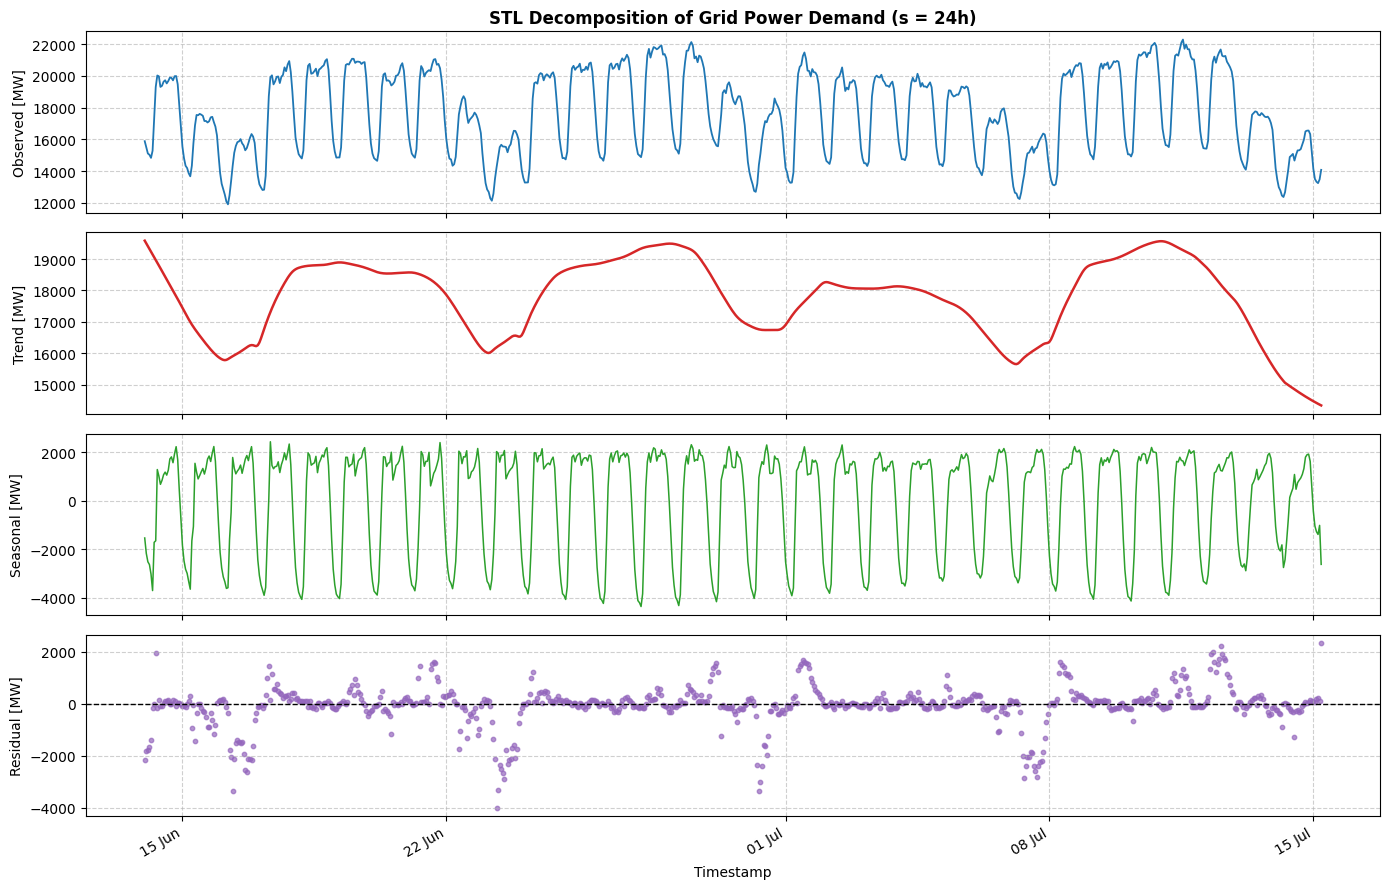

In [5]:
stl = STL(df['demand'], period=24, robust=True)
res_stl = stl.fit()

fig = plot_decomposition(res_stl, title='STL Decomposition of Grid Power Demand (s = 24h)')
plt.show()


### 5. Statistical Stationarity Tests (ADF / KPSS) & Autocorrelation (ACF / PACF)

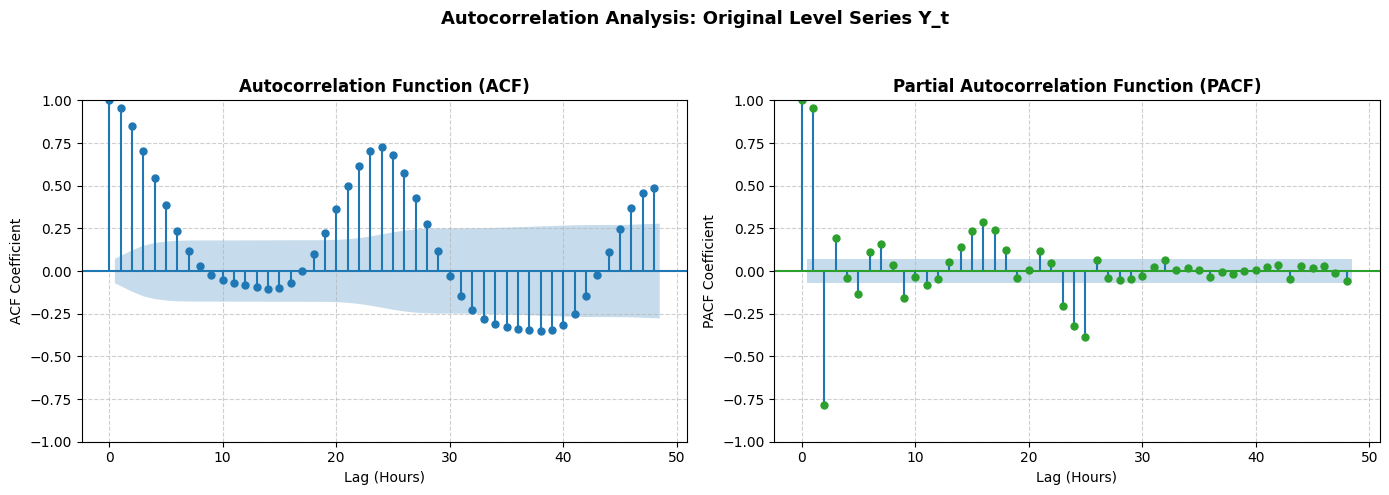

--- Stationarity Tests on Level Series (Y_t) ---
ADF Statistic: -1.549 (p-value = 5.0927e-01) -> Non-Stationary
KPSS Statistic: 0.087 (p-value = 1.0000e-01) -> Stationary
Conclusion: Series is difference-stationary (differencing d=1 recommended).


In [6]:
fig = plot_acf_pacf_custom(df['demand'], lags=48, title='Autocorrelation Analysis: Original Level Series Y_t')
plt.show()

stat_orig = check_stationarity(df['demand'])
print("--- Stationarity Tests on Level Series (Y_t) ---")
print(f"ADF Statistic: {stat_orig['adf']['statistic']:.3f} (p-value = {stat_orig['adf']['p_value']:.4e}) -> {'Stationary' if stat_orig['adf']['is_stationary'] else 'Non-Stationary'}")
print(f"KPSS Statistic: {stat_orig['kpss']['statistic']:.3f} (p-value = {stat_orig['kpss']['p_value']:.4e}) -> {'Stationary' if stat_orig['kpss']['is_stationary'] else 'Non-Stationary'}")
print(f"Conclusion: {stat_orig['conclusion']}")


### 6. Differencing Verification ($d=1, D=1, s=24$) & Overdifferencing Check ($D=2$)

--- VARIANCE COMPARISON: D=1 vs D=2 (OVERDIFFERENCING CHECK) ---
Variance for (d=1, D=1): 138891
Variance for (d=1, D=2): 348753 (Variance increased by +151.1% -> evidence of overdifferencing)


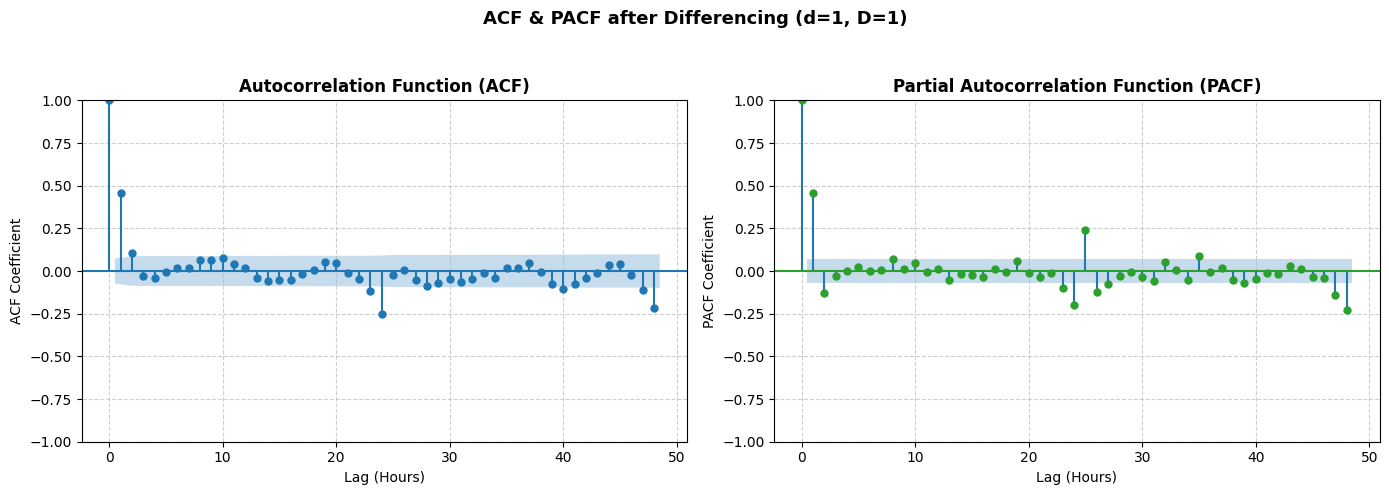

--- Stationarity Tests after Differencing (d=1, D=1) ---
ADF Statistic: -15.865 (p-value = 9.1123e-29) -> Stationary
KPSS Statistic: 0.025 (p-value = 1.0000e-01) -> Stationary
Conclusion: Series is strictly stationary (ADF and KPSS agree).


In [7]:
df['demand_diff_both'] = df['demand'].diff(1).diff(24)
diff_D1 = df['demand_diff_both'].dropna()
diff_D2 = df['demand'].diff(1).diff(24).diff(24).dropna()

var_D1 = np.var(diff_D1)
var_D2 = np.var(diff_D2)
var_increase = (var_D2 - var_D1) / var_D1 * 100

print("--- VARIANCE COMPARISON: D=1 vs D=2 (OVERDIFFERENCING CHECK) ---")
print(f"Variance for (d=1, D=1): {var_D1:.0f}")
print(f"Variance for (d=1, D=2): {var_D2:.0f} (Variance increased by +{var_increase:.1f}% -> evidence of overdifferencing)")

fig = plot_acf_pacf_custom(diff_D1, lags=48, title='ACF & PACF after Differencing (d=1, D=1)')
plt.show()

stat_diff = check_stationarity(diff_D1)
print("--- Stationarity Tests after Differencing (d=1, D=1) ---")
print(f"ADF Statistic: {stat_diff['adf']['statistic']:.3f} (p-value = {stat_diff['adf']['p_value']:.4e}) -> Stationary")
print(f"KPSS Statistic: {stat_diff['kpss']['statistic']:.3f} (p-value = {stat_diff['kpss']['p_value']:.4e}) -> Stationary")
print(f"Conclusion: {stat_diff['conclusion']}")


### Analytical Takeaways & Modeling Decisions:
* **Night Valley vs Midday Valley**:
  - Night trough (02:00-04:00) sees demand drop to ~14,246 MW due to lower domestic and industrial activity.
  - At midday (12:00), gross demand is high (~19,417 MW), but strong solar PV (~8,549 MW) and wind (~1,479 MW) generation reduce net demand to **9,389 MW** (Duck Curve trough).
  - During the evening peak (20:00), net demand surges to **17,379 MW** (a ramp of **+7,991 MW in 8 hours**).
* **Modeling Decision**: Differencing order (d=1, D=1) achieves strict stationarity. Adding D=2 increases variance by +151.1%, indicating overdifferencing. Solar PV and wind generation will be incorporated as exogenous features (X) in SARIMAX.
